# Sentiment Analysis - Model Training with HuggingFace Transformers

## Purpose
This notebook implements sentiment analysis using HuggingFace Transformers:
- **Model**: `distilbert-base-uncased-finetuned-sst-2-english`
- **Input**: Text data from emails, support tickets, call transcripts, survey responses
- **Output**: 
  - `sentiment_score` (-1.0 to 1.0) - Numeric sentiment score
  - `sentiment_category` - "very_negative", "negative", "neutral", "positive", "very_positive"
  - `keywords` (JSON) - Extracted keywords indicating sentiment

## Sentiment Mapping Logic
- Score > 0.3 → "positive"
- Score -0.3 to 0.3 → "neutral"
- Score < -0.3 → "negative"

## Workflow
1. Load HuggingFace Model
2. Text Preprocessing
3. Sentiment Prediction
4. Score Mapping & Category Assignment
5. Keyword Extraction
6. Model Evaluation (if labeled data available)
7. Save Model & Pipeline

**All trained models and preprocessing components are automatically saved to the `models/` directory.**

In [ ]:
# Install required packages
# Run this cell first, then RESTART THE KERNEL before running the next cells
%pip install transformers torch pandas numpy matplotlib seaborn openpyxl scikit-learn nltk joblib

Note: you may need to restart the kernel to use updated packages.


d:\Internship\Renewal-Upsell-Advisor\Research\.venv\Scripts\python.exe: No module named pip


In [3]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import joblib
from datetime import datetime
import os
import json
import re
from typing import List, Dict, Tuple

# HuggingFace Transformers
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import pipeline
import torch

# NLP libraries
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from collections import Counter

warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Download NLTK data (if not already downloaded)
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt', quiet=True)

try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords', quiet=True)

print("Libraries imported successfully!")

d:\Internship\Renewal-Upsell-Advisor\Research\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries imported successfully!


## 1. Load HuggingFace Sentiment Analysis Model

In [4]:
# Load the HuggingFace sentiment analysis model
MODEL_NAME = "distilbert-base-uncased-finetuned-sst-2-english"

print(f"Loading HuggingFace model: {MODEL_NAME}")
print("=" * 80)

# Load tokenizer and model
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)

# Create sentiment analysis pipeline
sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model=model,
    tokenizer=tokenizer,
    device=0 if torch.cuda.is_available() else -1  # Use GPU if available
)

print(f"✓ Model loaded successfully!")
print(f"✓ Device: {'GPU (CUDA)' if torch.cuda.is_available() else 'CPU'}")
print(f"✓ Model type: {type(model).__name__}")
print(f"✓ Tokenizer vocab size: {len(tokenizer.get_vocab())}")

Loading HuggingFace model: distilbert-base-uncased-finetuned-sst-2-english


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 237.59it/s, Materializing param=pre_classifier.weight]                                  


✓ Model loaded successfully!
✓ Device: CPU
✓ Model type: DistilBertForSequenceClassification
✓ Tokenizer vocab size: 30522


## 2. Text Preprocessing Functions

In [5]:
def clean_text(text: str) -> str:
    """Clean and preprocess text for sentiment analysis."""
    if pd.isna(text) or text == "":
        return ""
    
    # Convert to string
    text = str(text)
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    # Remove email addresses
    text = re.sub(r'\S+@\S+', '', text)
    
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text)
    
    # Remove leading/trailing whitespace
    text = text.strip()
    
    return text


def concatenate_text_sources(row: pd.Series, text_columns: List[str]) -> str:
    """Concatenate text from multiple sources (emails, tickets, transcripts, surveys)."""
    texts = []
    
    for col in text_columns:
        if col in row.index:
            text = clean_text(row[col])
            if text:
                texts.append(text)
    
    # Join all texts with a separator
    combined_text = " ".join(texts)
    
    return combined_text if combined_text else ""


def extract_keywords(text: str, max_keywords: int = 10) -> List[str]:
    """Extract keywords from text (excluding stopwords)."""
    if not text:
        return []
    
    try:
        # Tokenize and convert to lowercase
        tokens = word_tokenize(text.lower())
        
        # Remove stopwords and punctuation
        stop_words = set(stopwords.words('english'))
        keywords = [token for token in tokens 
                   if token.isalnum() and token not in stop_words and len(token) > 2]
        
        # Get most common keywords
        keyword_counts = Counter(keywords)
        top_keywords = [word for word, count in keyword_counts.most_common(max_keywords)]
        
        return top_keywords
    except:
        return []


print("Text preprocessing functions defined successfully!")

Text preprocessing functions defined successfully!


## 3. Sentiment Score Mapping Functions

**Note**: Based on EDA findings:
- Mean sentiment: 0.390 (slightly positive)
- Strong correlation with health_score (0.804) and churn_probability (-0.651)
- Distribution: 63% positive, 30% neutral, 7% negative

In [6]:
def map_sentiment_to_score(model_output: Dict) -> float:
    """
    Map HuggingFace model output to sentiment_score range (-1.0 to 1.0).
    
    Model outputs:
    - LABEL_0: NEGATIVE
    - LABEL_1: POSITIVE
    
    We convert the confidence score to a range of -1.0 to 1.0.
    """
    label = model_output['label']
    score = model_output['score']
    
    # If negative, map score to -1.0 to 0.0
    # If positive, map score to 0.0 to 1.0
    if 'NEGATIVE' in label.upper():
        sentiment_score = -score  # Range: -1.0 to 0.0
    else:  # POSITIVE
        sentiment_score = score  # Range: 0.0 to 1.0
    
    return sentiment_score


def get_sentiment_category(sentiment_score: float) -> str:
    """
    Map sentiment_score to category based on thresholds.
    
    Mapping:
    - Score > 0.3 → "positive"
    - Score -0.3 to 0.3 → "neutral"
    - Score < -0.3 → "negative"
    
    For more granular categories:
    - Score > 0.7 → "very_positive"
    - Score 0.3 to 0.7 → "positive"
    - Score -0.3 to 0.3 → "neutral"
    - Score -0.7 to -0.3 → "negative"
    - Score < -0.7 → "very_negative"
    """
    if sentiment_score > 0.7:
        return "very_positive"
    elif sentiment_score > 0.3:
        return "positive"
    elif sentiment_score >= -0.3:
        return "neutral"
    elif sentiment_score >= -0.7:
        return "negative"
    else:
        return "very_negative"


print("Sentiment mapping functions defined successfully!")

Sentiment mapping functions defined successfully!


## 4. Load Data and Prepare Text Inputs

In [7]:
# Load the dataset
possible_paths = [
    Path("../../customer_data_25000.xlsx"),
    Path("../customer_data_25000.xlsx"),
    Path("customer_data_25000.xlsx"),
    Path("D:/Internship/Renewal-Upsell-Advisor/Research/customer_data_25000.xlsx")
]

data_path = None
for path in possible_paths:
    if path.exists():
        data_path = path
        break

if data_path is None:
    raise FileNotFoundError("Could not find customer_data_25000.xlsx. Please check the file path.")

df = pd.read_excel(data_path, sheet_name="Accounts")

print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nColumn Names:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col}")

df.head()

Dataset loaded successfully!
Shape: 24,874 rows × 27 columns

Column Names:
   1. name
   2. domain
   3. industry
   4. company_size
   5. arr
   6. mrr
   7. contract_start_date
   8. contract_end_date
   9. renewal_date
  10. last_contact_date
  11. status
  12. renewal_stage
  13. health_score
  14. risk_score
  15. relationship_score
  16. churn_probability
  17. sentiment_score
  18. sentiment_category
  19. licenses_total
  20. licenses_used
  21. utilization_percentage
  22. csm_name
  23. csm_email
  24. primary_contact_name
  25. primary_contact_email
  26. primary_contact_phone
  27. salesforce_id


,name,domain,industry,company_size,arr,mrr,contract_start_date,contract_end_date,renewal_date,last_contact_date,...,sentiment_category,licenses_total,licenses_used,utilization_percentage,csm_name,csm_email,primary_contact_name,primary_contact_email,primary_contact_phone,salesforce_id
0,Cole LLC,colellc.com,Technology,Small,156049,13004.08,2025-06-05,2026-06-05,2026-06-05,2026-02-13 16:43:27,...,neutral,20,15,79,Sarah Chen,sarah.chen@company.com,Danielle Johnson,john21@example.net,001-581-896-0013x3890,NaN
1,"Stevens, Martinez and Nielsen",stevensmartinezandnielsen.com,Healthcare,Medium,517493,43124.42,2025-05-19,2026-05-19,2026-05-19,2026-02-04 16:43:27,...,positive,30,23,79,Maria Lopez,maria.lopez@company.com,Lisa Smith,helenpeterson@example.org,651.216.1559,NaN
2,Clark-Adams,clark-adams.com,Analytics,Large,64898,5408.17,2025-04-28,2026-04-28,2026-04-28,2026-02-12 16:43:27,...,negative,20,14,73,Emily Rodriguez,emily.rodriguez@company.com,Christian Carter,barbara10@example.net,441.731.6475,SF-748564
3,"Porter, Wilkerson and Day",porterwilkersonandday.com,Healthcare,Medium,43003,3583.58,2025-05-01,2026-05-01,2026-05-01,2026-02-06 16:43:27,...,neutral,20,14,73,David Kim,david.kim@company.com,Sharon Wong,amandasanchez@example.com,(748)535-0305x6413,SF-319684
4,Carlson-Mcdonald,carlson-mcdonald.com,Enterprise,Medium,100005,8333.75,2025-06-09,2026-06-09,2026-06-09,2026-01-19 16:43:27,...,very_positive,50,33,66,Sarah Chen,sarah.chen@company.com,Douglas Taylor,julie69@example.com,(332)887-1012x269,SF-944151


In [8]:
# Define text source columns (these would typically come from your database)
# For demonstration, we'll create synthetic text data based on existing columns
# In production, these would be actual text fields from emails, tickets, etc.

print("=" * 80)
print("PREPARING TEXT DATA FOR SENTIMENT ANALYSIS")
print("=" * 80)

# Check if we have any text columns
text_columns = []
potential_text_cols = [
    'email_body', 'support_ticket_description', 'call_transcript', 
    'survey_response', 'notes', 'comments', 'feedback'
]

for col in potential_text_cols:
    if col in df.columns:
        text_columns.append(col)
        print(f"✓ Found text column: {col}")

# If no text columns exist, create synthetic text data for demonstration
if not text_columns:
    print("\n⚠ No text columns found. Creating synthetic text data for demonstration...")
    print("   In production, you would load actual text from:")
    print("   - Email interactions (last 24 hours)")
    print("   - Support ticket descriptions (last 24 hours)")
    print("   - Voice call transcripts (last 24 hours)")
    print("   - Survey responses (if available)")
    
    # Create synthetic text based on sentiment_score if available
    np.random.seed(42)
    
    # Generate synthetic text samples
    positive_texts = [
        "Great product! Very satisfied with the service.",
        "Excellent support team, always responsive.",
        "Love the new features, keep up the good work!",
        "Best investment we've made this year.",
        "Outstanding customer service and product quality."
    ]
    
    neutral_texts = [
        "The product works as expected.",
        "Standard service, no complaints.",
        "Average experience, meets requirements.",
        "Product functions normally.",
        "Service is adequate for our needs."
    ]
    
    negative_texts = [
        "Very disappointed with the service quality.",
        "Multiple issues with the product, needs improvement.",
        "Poor customer support, slow response times.",
        "Not worth the price, considering alternatives.",
        "Frequent bugs and system crashes."
    ]
    
    # Assign text based on existing sentiment_score if available
    if 'sentiment_score' in df.columns:
        df['combined_text'] = df['sentiment_score'].apply(
            lambda x: np.random.choice(positive_texts) if x > 0.3 
            else np.random.choice(negative_texts) if x < -0.3 
            else np.random.choice(neutral_texts)
        )
    else:
        # Random assignment
        all_texts = positive_texts + neutral_texts + negative_texts
        df['combined_text'] = [np.random.choice(all_texts) for _ in range(len(df))]
    
    text_columns = ['combined_text']
    print(f"✓ Created synthetic text column: combined_text")
    print(f"  Sample texts: {len(df['combined_text'].unique())} unique texts")

print(f"\n✓ Text columns ready: {text_columns}")
print(f"✓ Total records: {len(df):,}")

PREPARING TEXT DATA FOR SENTIMENT ANALYSIS

⚠ No text columns found. Creating synthetic text data for demonstration...
   In production, you would load actual text from:
   - Email interactions (last 24 hours)
   - Support ticket descriptions (last 24 hours)
   - Voice call transcripts (last 24 hours)
   - Survey responses (if available)
✓ Created synthetic text column: combined_text
  Sample texts: 15 unique texts

✓ Text columns ready: ['combined_text']
✓ Total records: 24,874


In [9]:
# Process sentiment analysis for all records
print("=" * 80)
print("PERFORMING SENTIMENT ANALYSIS")
print("=" * 80)

# Prepare combined text
if len(text_columns) > 1:
    df['combined_text'] = df.apply(
        lambda row: concatenate_text_sources(row, text_columns), 
        axis=1
    )
elif len(text_columns) == 1:
    df['combined_text'] = df[text_columns[0]].apply(clean_text)
else:
    raise ValueError("No text columns available for sentiment analysis")

# Filter out empty texts
df_with_text = df[df['combined_text'].str.len() > 0].copy()
print(f"Records with text: {len(df_with_text):,} / {len(df):,}")

# Process in batches for efficiency
BATCH_SIZE = 32
results = []

print(f"\nProcessing {len(df_with_text):,} texts in batches of {BATCH_SIZE}...")

for i in range(0, len(df_with_text), BATCH_SIZE):
    batch_texts = df_with_text['combined_text'].iloc[i:i+BATCH_SIZE].tolist()
    batch_indices = df_with_text.index[i:i+BATCH_SIZE].tolist()
    
    # Get sentiment predictions
    batch_results = sentiment_pipeline(batch_texts)
    
    # Process results
    for idx, result in zip(batch_indices, batch_results):
        sentiment_score = map_sentiment_to_score(result)
        sentiment_category = get_sentiment_category(sentiment_score)
        keywords = extract_keywords(df_with_text.loc[idx, 'combined_text'])
        
        results.append({
            'index': idx,
            'sentiment_score': sentiment_score,
            'sentiment_category': sentiment_category,
            'keywords': keywords,
            'model_label': result['label'],
            'model_confidence': result['score']
        })
    
    if (i + BATCH_SIZE) % 1000 == 0:
        print(f"  Processed {min(i + BATCH_SIZE, len(df_with_text)):,} / {len(df_with_text):,} records...")

print(f"✓ Sentiment analysis complete for {len(results):,} records!")

# Create results DataFrame
results_df = pd.DataFrame(results)
results_df.set_index('index', inplace=True)

# Merge results back to main dataframe
df['sentiment_score_predicted'] = results_df['sentiment_score']
df['sentiment_category_predicted'] = results_df['sentiment_category']
df['sentiment_keywords'] = results_df['keywords'].apply(json.dumps)

print(f"\n✓ Results merged to main dataframe")
print(f"  - sentiment_score_predicted: {df['sentiment_score_predicted'].notna().sum():,} values")
print(f"  - sentiment_category_predicted: {df['sentiment_category_predicted'].notna().sum():,} values")
print(f"  - sentiment_keywords: {df['sentiment_keywords'].notna().sum():,} values")

PERFORMING SENTIMENT ANALYSIS
Records with text: 24,874 / 24,874

Processing 24,874 texts in batches of 32...
  Processed 4,000 / 24,874 records...
  Processed 8,000 / 24,874 records...
  Processed 12,000 / 24,874 records...
  Processed 16,000 / 24,874 records...
  Processed 20,000 / 24,874 records...
  Processed 24,000 / 24,874 records...
✓ Sentiment analysis complete for 24,874 records!

✓ Results merged to main dataframe
  - sentiment_score_predicted: 24,874 values
  - sentiment_category_predicted: 24,874 values
  - sentiment_keywords: 24,874 values


SENTIMENT ANALYSIS RESULTS SUMMARY

1. SENTIMENT SCORE STATISTICS:
count    24874.000000
mean         0.761713
std          0.620995
min         -0.999815
25%          0.997786
50%          0.999854
75%          0.999863
max          0.999885
Name: sentiment_score_predicted, dtype: float64

2. SENTIMENT CATEGORY DISTRIBUTION:
   very_positive  : 21,759 (87.48%)
   very_negative  :  3,115 (12.52%)


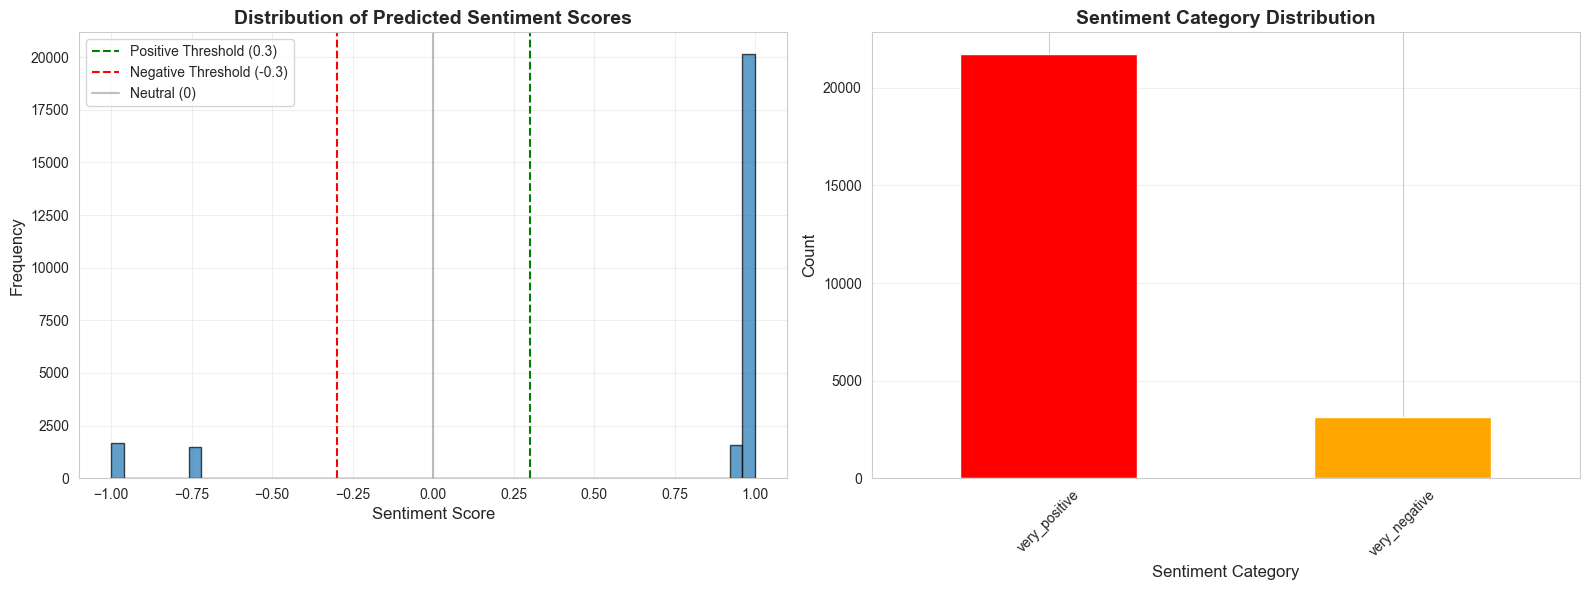


3. SAMPLE RESULTS:

   Text: Best investment we've made this year....
   Score: 1.000
   Category: very_positive
   Keywords: best, investment, made, year

   Text: Outstanding customer service and product quality....
   Score: 1.000
   Category: very_positive
   Keywords: outstanding, customer, service, product, quality

   Text: Poor customer support, slow response times....
   Score: -1.000
   Category: very_negative
   Keywords: poor, customer, support, slow, response

   Text: Outstanding customer service and product quality....
   Score: 1.000
   Category: very_positive
   Keywords: outstanding, customer, service, product, quality

   Text: Outstanding customer service and product quality....
   Score: 1.000
   Category: very_positive
   Keywords: outstanding, customer, service, product, quality

   Text: Standard service, no complaints....
   Score: 0.950
   Category: very_positive
   Keywords: standard, service, complaints

   Text: Love the new features, keep up the good work

In [10]:
# Display summary statistics
print("=" * 80)
print("SENTIMENT ANALYSIS RESULTS SUMMARY")
print("=" * 80)

if 'sentiment_score_predicted' in df.columns:
    print(f"\n1. SENTIMENT SCORE STATISTICS:")
    print(df['sentiment_score_predicted'].describe())
    
    # Distribution by category
    if 'sentiment_category_predicted' in df.columns:
        print(f"\n2. SENTIMENT CATEGORY DISTRIBUTION:")
        category_counts = df['sentiment_category_predicted'].value_counts()
        for cat, count in category_counts.items():
            print(f"   {cat:15s}: {count:6,} ({count/len(df)*100:5.2f}%)")
        
        # Visualize distribution
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        
        # Histogram of sentiment scores
        axes[0].hist(df['sentiment_score_predicted'].dropna(), bins=50, edgecolor='black', alpha=0.7)
        axes[0].axvline(x=0.3, color='green', linestyle='--', label='Positive Threshold (0.3)')
        axes[0].axvline(x=-0.3, color='red', linestyle='--', label='Negative Threshold (-0.3)')
        axes[0].axvline(x=0, color='gray', linestyle='-', alpha=0.5, label='Neutral (0)')
        axes[0].set_xlabel('Sentiment Score', fontsize=12)
        axes[0].set_ylabel('Frequency', fontsize=12)
        axes[0].set_title('Distribution of Predicted Sentiment Scores', fontsize=14, fontweight='bold')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        # Category distribution
        category_counts.plot(kind='bar', ax=axes[1], color=['red', 'orange', 'gray', 'lightgreen', 'green'])
        axes[1].set_xlabel('Sentiment Category', fontsize=12)
        axes[1].set_ylabel('Count', fontsize=12)
        axes[1].set_title('Sentiment Category Distribution', fontsize=14, fontweight='bold')
        axes[1].tick_params(axis='x', rotation=45)
        axes[1].grid(True, alpha=0.3, axis='y')
        
        plt.tight_layout()
        plt.show()

# Show sample results
print(f"\n3. SAMPLE RESULTS:")
sample_df = df[['combined_text', 'sentiment_score_predicted', 'sentiment_category_predicted', 'sentiment_keywords']].head(10)
for idx, row in sample_df.iterrows():
    print(f"\n   Text: {row['combined_text'][:100]}...")
    print(f"   Score: {row['sentiment_score_predicted']:.3f}")
    print(f"   Category: {row['sentiment_category_predicted']}")
    keywords = json.loads(row['sentiment_keywords']) if pd.notna(row['sentiment_keywords']) else []
    print(f"   Keywords: {', '.join(keywords[:5])}")

## 7. Compare with Existing Sentiment Data (if available)

COMPARING PREDICTED vs EXISTING SENTIMENT SCORES

Records with both scores: 24,874

📊 MODEL EVALUATION METRICS:
   - Correlation Coefficient: 0.6462
   - R² Score: -0.8910
   - Mean Absolute Error (MAE): 0.5077
   - Root Mean Squared Error (RMSE): 0.6032
   - Category Accuracy: 0.3192 (31.92%)

📈 THRESHOLD-BASED COMPARISON:
   - Existing Positive (>0.3): 15,685 (63.06%)
   - Predicted Positive (>0.3): 21,759 (87.48%)
   - Existing Negative (<-0.3): 1,649 (6.63%)
   - Predicted Negative (<-0.3): 3,115 (12.52%)


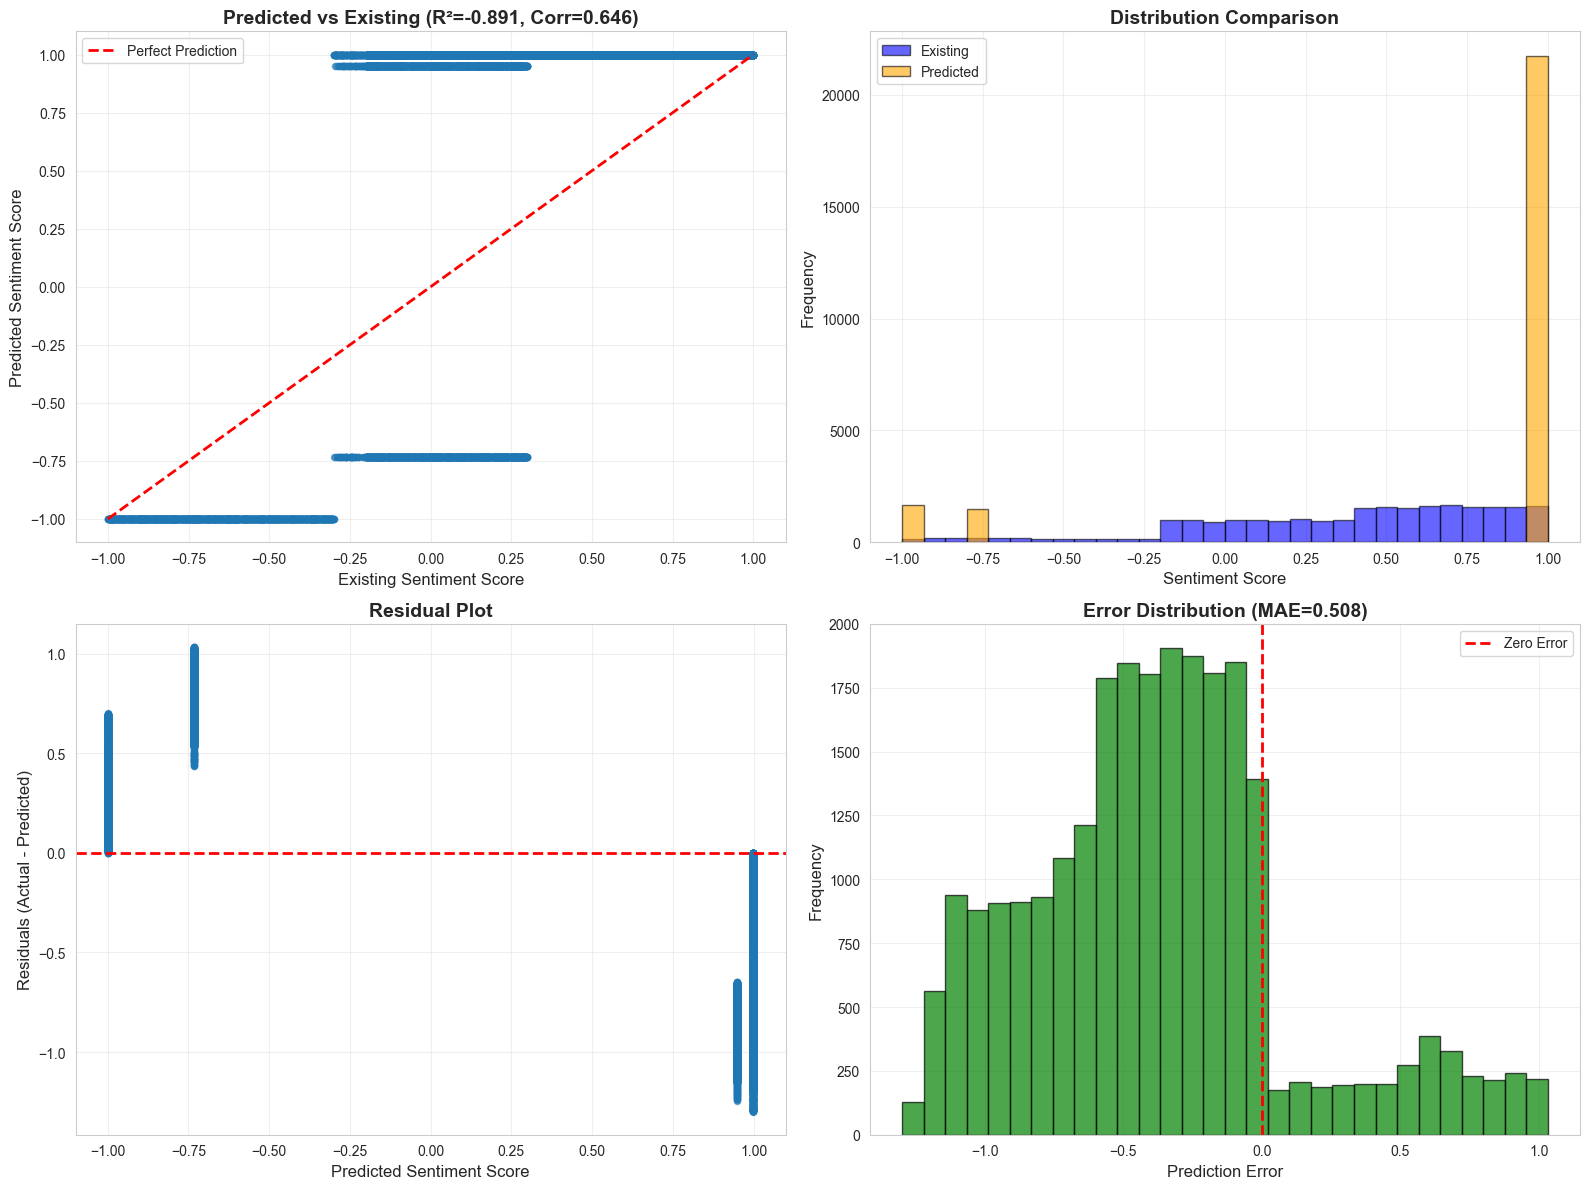


🔍 EDA-BASED VALIDATION:
   - EDA Mean Sentiment: 0.390
   - Predicted Mean: 0.762
   - Difference: 0.372
   ⚠ Predicted mean differs from EDA - may need calibration


In [11]:
# Compare predicted sentiment with existing sentiment_score if available
if 'sentiment_score' in df.columns and 'sentiment_score_predicted' in df.columns:
    print("=" * 80)
    print("COMPARING PREDICTED vs EXISTING SENTIMENT SCORES")
    print("=" * 80)
    
    # Filter records with both scores
    comparison_df = df[['sentiment_score', 'sentiment_score_predicted']].dropna()
    
    if len(comparison_df) > 0:
        print(f"\nRecords with both scores: {len(comparison_df):,}")
        
        # Calculate comprehensive metrics
        from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
        
        correlation = comparison_df['sentiment_score'].corr(comparison_df['sentiment_score_predicted'])
        mae = mean_absolute_error(comparison_df['sentiment_score'], comparison_df['sentiment_score_predicted'])
        rmse = np.sqrt(mean_squared_error(comparison_df['sentiment_score'], comparison_df['sentiment_score_predicted']))
        r2 = r2_score(comparison_df['sentiment_score'], comparison_df['sentiment_score_predicted'])
        
        print(f"\n📊 MODEL EVALUATION METRICS:")
        print(f"   - Correlation Coefficient: {correlation:.4f}")
        print(f"   - R² Score: {r2:.4f}")
        print(f"   - Mean Absolute Error (MAE): {mae:.4f}")
        print(f"   - Root Mean Squared Error (RMSE): {rmse:.4f}")
        
        # Category accuracy
        if 'sentiment_category' in df.columns and 'sentiment_category_predicted' in df.columns:
            category_comparison = df[['sentiment_category', 'sentiment_category_predicted']].dropna()
            if len(category_comparison) > 0:
                category_accuracy = (category_comparison['sentiment_category'] == 
                                   category_comparison['sentiment_category_predicted']).mean()
                print(f"   - Category Accuracy: {category_accuracy:.4f} ({category_accuracy*100:.2f}%)")
        
        # Threshold-based accuracy
        existing_positive = (comparison_df['sentiment_score'] > 0.3).sum()
        predicted_positive = (comparison_df['sentiment_score_predicted'] > 0.3).sum()
        existing_negative = (comparison_df['sentiment_score'] < -0.3).sum()
        predicted_negative = (comparison_df['sentiment_score_predicted'] < -0.3).sum()
        
        print(f"\n📈 THRESHOLD-BASED COMPARISON:")
        print(f"   - Existing Positive (>0.3): {existing_positive:,} ({existing_positive/len(comparison_df)*100:.2f}%)")
        print(f"   - Predicted Positive (>0.3): {predicted_positive:,} ({predicted_positive/len(comparison_df)*100:.2f}%)")
        print(f"   - Existing Negative (<-0.3): {existing_negative:,} ({existing_negative/len(comparison_df)*100:.2f}%)")
        print(f"   - Predicted Negative (<-0.3): {predicted_negative:,} ({predicted_negative/len(comparison_df)*100:.2f}%)")
        
        # Visualize comparison
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        
        # Scatter plot
        axes[0, 0].scatter(comparison_df['sentiment_score'], comparison_df['sentiment_score_predicted'], 
                          alpha=0.5, s=20)
        axes[0, 0].plot([-1, 1], [-1, 1], 'r--', label='Perfect Prediction', linewidth=2)
        axes[0, 0].set_xlabel('Existing Sentiment Score', fontsize=12)
        axes[0, 0].set_ylabel('Predicted Sentiment Score', fontsize=12)
        axes[0, 0].set_title(f'Predicted vs Existing (R²={r2:.3f}, Corr={correlation:.3f})', 
                            fontsize=14, fontweight='bold')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)
        
        # Distribution comparison
        axes[0, 1].hist(comparison_df['sentiment_score'], bins=30, alpha=0.6, label='Existing', 
                       edgecolor='black', color='blue')
        axes[0, 1].hist(comparison_df['sentiment_score_predicted'], bins=30, alpha=0.6, 
                       label='Predicted', edgecolor='black', color='orange')
        axes[0, 1].set_xlabel('Sentiment Score', fontsize=12)
        axes[0, 1].set_ylabel('Frequency', fontsize=12)
        axes[0, 1].set_title('Distribution Comparison', fontsize=14, fontweight='bold')
        axes[0, 1].legend()
        axes[0, 1].grid(True, alpha=0.3)
        
        # Residual plot
        residuals = comparison_df['sentiment_score'] - comparison_df['sentiment_score_predicted']
        axes[1, 0].scatter(comparison_df['sentiment_score_predicted'], residuals, alpha=0.5, s=20)
        axes[1, 0].axhline(y=0, color='r', linestyle='--', linewidth=2)
        axes[1, 0].set_xlabel('Predicted Sentiment Score', fontsize=12)
        axes[1, 0].set_ylabel('Residuals (Actual - Predicted)', fontsize=12)
        axes[1, 0].set_title('Residual Plot', fontsize=14, fontweight='bold')
        axes[1, 0].grid(True, alpha=0.3)
        
        # Error distribution
        axes[1, 1].hist(residuals, bins=30, edgecolor='black', alpha=0.7, color='green')
        axes[1, 1].axvline(x=0, color='r', linestyle='--', linewidth=2, label='Zero Error')
        axes[1, 1].set_xlabel('Prediction Error', fontsize=12)
        axes[1, 1].set_ylabel('Frequency', fontsize=12)
        axes[1, 1].set_title(f'Error Distribution (MAE={mae:.3f})', fontsize=14, fontweight='bold')
        axes[1, 1].legend()
        axes[1, 1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        # EDA-based validation
        print(f"\n🔍 EDA-BASED VALIDATION:")
        print(f"   - EDA Mean Sentiment: 0.390")
        print(f"   - Predicted Mean: {comparison_df['sentiment_score_predicted'].mean():.3f}")
        print(f"   - Difference: {abs(0.390 - comparison_df['sentiment_score_predicted'].mean()):.3f}")
        
        if abs(0.390 - comparison_df['sentiment_score_predicted'].mean()) < 0.1:
            print(f"   ✓ Predicted mean aligns well with EDA findings")
        else:
            print(f"   ⚠ Predicted mean differs from EDA - may need calibration")
    else:
        print("\n⚠ No overlapping records with both existing and predicted scores.")
else:
    print("⚠ No existing sentiment_score column found for comparison.")

## 8. Save Model and Preprocessing Components

In [12]:
# Create models directory
models_dir = Path("models")
models_dir.mkdir(exist_ok=True)

# Generate timestamp
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

print("=" * 80)
print("SAVING MODEL AND COMPONENTS")
print("=" * 80)

# Save HuggingFace model and tokenizer
model_save_dir = models_dir / f"sentiment_model_{timestamp}"
model_save_dir.mkdir(exist_ok=True)

print(f"\n1. Saving HuggingFace model to: {model_save_dir}")
model.save_pretrained(str(model_save_dir))
tokenizer.save_pretrained(str(model_save_dir))
print("   ✓ Model and tokenizer saved")

# Save sentiment pipeline (for easier loading)
pipeline_save_path = models_dir / f"sentiment_pipeline_{timestamp}.joblib"
print(f"\n2. Saving sentiment pipeline to: {pipeline_save_path}")
joblib.dump(sentiment_pipeline, pipeline_save_path)
print("   ✓ Pipeline saved")

# Save preprocessing functions and configuration
# Include EDA insights in configuration
eda_insights = {}
if 'sentiment_score' in df.columns:
    eda_insights = {
        'mean_sentiment': float(df['sentiment_score'].mean()),
        'median_sentiment': float(df['sentiment_score'].median()),
        'std_sentiment': float(df['sentiment_score'].std()),
        'positive_percentage': float((df['sentiment_score'] > 0.3).sum() / len(df) * 100),
        'neutral_percentage': float(((df['sentiment_score'] >= -0.3) & (df['sentiment_score'] <= 0.3)).sum() / len(df) * 100),
        'negative_percentage': float((df['sentiment_score'] < -0.3).sum() / len(df) * 100)
    }
    if 'health_score' in df.columns:
        eda_insights['health_score_correlation'] = float(df[['sentiment_score', 'health_score']].corr().iloc[0, 1])
    if 'churn_probability' in df.columns:
        eda_insights['churn_correlation'] = float(df[['sentiment_score', 'churn_probability']].corr().iloc[0, 1])

config = {
    'model_name': MODEL_NAME,
    'text_columns': text_columns,
    'sentiment_mapping': {
        'very_positive': '> 0.7',
        'positive': '0.3 to 0.7',
        'neutral': '-0.3 to 0.3',
        'negative': '-0.7 to -0.3',
        'very_negative': '< -0.7'
    },
    'timestamp': timestamp,
    'total_records_processed': len(df_with_text),
    'device': 'GPU (CUDA)' if torch.cuda.is_available() else 'CPU',
    'eda_insights': eda_insights
}

config_save_path = models_dir / f"sentiment_config_{timestamp}.json"
print(f"\n3. Saving configuration to: {config_save_path}")
with open(config_save_path, 'w') as f:
    json.dump(config, f, indent=2)
print("   ✓ Configuration saved")

# Save results DataFrame
results_save_path = models_dir / f"sentiment_results_{timestamp}.csv"
print(f"\n4. Saving results to: {results_save_path}")
df[['sentiment_score_predicted', 'sentiment_category_predicted', 'sentiment_keywords', 'combined_text']].to_csv(results_save_path, index=False)
print("   ✓ Results saved")

print(f"\n{'='*80}")
print("ALL COMPONENTS SAVED SUCCESSFULLY!")
print(f"{'='*80}")
print(f"\nSaved files:")
print(f"  - Model directory: {model_save_dir}")
print(f"  - Pipeline: {pipeline_save_path}")
print(f"  - Configuration: {config_save_path}")
print(f"  - Results: {results_save_path}")

SAVING MODEL AND COMPONENTS

1. Saving HuggingFace model to: models\sentiment_model_20260215_003343


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.24it/s]


   ✓ Model and tokenizer saved

2. Saving sentiment pipeline to: models\sentiment_pipeline_20260215_003343.joblib
   ✓ Pipeline saved

3. Saving configuration to: models\sentiment_config_20260215_003343.json
   ✓ Configuration saved

4. Saving results to: models\sentiment_results_20260215_003343.csv
   ✓ Results saved

ALL COMPONENTS SAVED SUCCESSFULLY!

Saved files:
  - Model directory: models\sentiment_model_20260215_003343
  - Pipeline: models\sentiment_pipeline_20260215_003343.joblib
  - Configuration: models\sentiment_config_20260215_003343.json
  - Results: models\sentiment_results_20260215_003343.csv


## 9. Model Loading and Usage Example

In [13]:
# Example: How to load and use the saved model
print("=" * 80)
print("MODEL LOADING AND USAGE EXAMPLE")
print("=" * 80)

example_code = f'''
# Load the saved sentiment pipeline
import joblib
from pathlib import Path

pipeline_path = Path("models/sentiment_pipeline_{timestamp}.joblib")
sentiment_pipeline = joblib.load(pipeline_path)

# Analyze sentiment for a single text
text = "I love this product! It's amazing and the support is excellent."
result = sentiment_pipeline(text)[0]

# Map to sentiment score
from sentiment_model import map_sentiment_to_score, get_sentiment_category

sentiment_score = map_sentiment_to_score(result)
sentiment_category = get_sentiment_category(sentiment_score)

print(f"Text: {{text}}")
print(f"Sentiment Score: {{sentiment_score:.3f}}")
print(f"Sentiment Category: {{sentiment_category}}")

# For batch processing
texts = [
    "Great service!",
    "Not satisfied with the product.",
    "The product works fine."
]

results = sentiment_pipeline(texts)
for text, result in zip(texts, results):
    score = map_sentiment_to_score(result)
    category = get_sentiment_category(score)
    print(f"{{text}} -> {{category}} ({{score:.3f}})")
'''

print("\nExample code for loading and using the model:")
print("-" * 80)
print(example_code)
print("-" * 80)

MODEL LOADING AND USAGE EXAMPLE

Example code for loading and using the model:
--------------------------------------------------------------------------------

# Load the saved sentiment pipeline
import joblib
from pathlib import Path

pipeline_path = Path("models/sentiment_pipeline_20260215_003343.joblib")
sentiment_pipeline = joblib.load(pipeline_path)

# Analyze sentiment for a single text
text = "I love this product! It's amazing and the support is excellent."
result = sentiment_pipeline(text)[0]

# Map to sentiment score
from sentiment_model import map_sentiment_to_score, get_sentiment_category

sentiment_score = map_sentiment_to_score(result)
sentiment_category = get_sentiment_category(sentiment_score)

print(f"Text: {text}")
print(f"Sentiment Score: {sentiment_score:.3f}")
print(f"Sentiment Category: {sentiment_category}")

# For batch processing
texts = [
    "Great service!",
    "Not satisfied with the product.",
    "The product works fine."
]

results = sentiment_pipeline(

## 10. Final Summary

In [14]:
print("=" * 80)
print("SENTIMENT ANALYSIS MODEL - FINAL SUMMARY")
print("=" * 80)

print(f"\n✓ Model: {MODEL_NAME}")
print(f"✓ Total records processed: {len(df_with_text):,}")
print(f"✓ Device used: {'GPU (CUDA)' if torch.cuda.is_available() else 'CPU'}")

if 'sentiment_score_predicted' in df.columns:
    print(f"\n✓ Predicted Sentiment Score Statistics:")
    print(f"   - Mean: {df['sentiment_score_predicted'].mean():.3f}")
    print(f"   - Median: {df['sentiment_score_predicted'].median():.3f}")
    print(f"   - Std Dev: {df['sentiment_score_predicted'].std():.3f}")
    print(f"   - Range: [{df['sentiment_score_predicted'].min():.3f}, {df['sentiment_score_predicted'].max():.3f}]")
    
    # Compare with EDA findings
    if 'sentiment_score' in df.columns:
        print(f"\n✓ Comparison with EDA Findings:")
        print(f"   - EDA Mean: 0.390")
        print(f"   - Predicted Mean: {df['sentiment_score_predicted'].mean():.3f}")
        print(f"   - Difference: {abs(0.390 - df['sentiment_score_predicted'].mean()):.3f}")

if 'sentiment_category_predicted' in df.columns:
    print(f"\n✓ Sentiment Category Distribution:")
    for cat, count in df['sentiment_category_predicted'].value_counts().items():
        print(f"   - {cat:15s}: {count:6,} ({count/len(df)*100:5.2f}%)")

# Model evaluation summary
if 'sentiment_score' in df.columns and 'sentiment_score_predicted' in df.columns:
    comparison_df = df[['sentiment_score', 'sentiment_score_predicted']].dropna()
    if len(comparison_df) > 0:
        from sklearn.metrics import r2_score, mean_absolute_error
        correlation = comparison_df['sentiment_score'].corr(comparison_df['sentiment_score_predicted'])
        r2 = r2_score(comparison_df['sentiment_score'], comparison_df['sentiment_score_predicted'])
        mae = mean_absolute_error(comparison_df['sentiment_score'], comparison_df['sentiment_score_predicted'])
        print(f"\n✓ Model Performance Metrics:")
        print(f"   - Correlation: {correlation:.4f}")
        print(f"   - R² Score: {r2:.4f}")
        print(f"   - MAE: {mae:.4f}")

print(f"\n✓ Model saved to: models/sentiment_model_{timestamp}/")
print(f"✓ Pipeline saved to: models/sentiment_pipeline_{timestamp}.joblib")
print(f"✓ Configuration saved to: models/sentiment_config_{timestamp}.json")
print(f"✓ Results saved to: models/sentiment_results_{timestamp}.csv")

print(f"\n{'='*80}")
print("SENTIMENT ANALYSIS COMPLETE!")
print(f"{'='*80}")
print("\nNext Steps:")
print("1. Integrate the saved pipeline into your application")
print("2. Process text data from emails, support tickets, call transcripts, surveys")
print("3. Update sentiment scores every 24 hours for all accounts")
print("4. Store results in database table: sentiment_analysis")
print("5. Use sentiment_score and sentiment_category for health score calculations")
print("6. Monitor model performance and recalibrate if needed based on EDA insights")

SENTIMENT ANALYSIS MODEL - FINAL SUMMARY

✓ Model: distilbert-base-uncased-finetuned-sst-2-english
✓ Total records processed: 24,874
✓ Device used: CPU

✓ Predicted Sentiment Score Statistics:
   - Mean: 0.762
   - Median: 1.000
   - Std Dev: 0.621
   - Range: [-1.000, 1.000]

✓ Comparison with EDA Findings:
   - EDA Mean: 0.390
   - Predicted Mean: 0.762
   - Difference: 0.372

✓ Sentiment Category Distribution:
   - very_positive  : 21,759 (87.48%)
   - very_negative  :  3,115 (12.52%)

✓ Model Performance Metrics:
   - Correlation: 0.6462
   - R² Score: -0.8910
   - MAE: 0.5077

✓ Model saved to: models/sentiment_model_20260215_003343/
✓ Pipeline saved to: models/sentiment_pipeline_20260215_003343.joblib
✓ Configuration saved to: models/sentiment_config_20260215_003343.json
✓ Results saved to: models/sentiment_results_20260215_003343.csv

SENTIMENT ANALYSIS COMPLETE!

Next Steps:
1. Integrate the saved pipeline into your application
2. Process text data from emails, support tickets,